In [122]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [123]:
load_dotenv()


True

In [124]:
model= ChatGoogleGenerativeAI(model='gemini-3.8-flash')

In [125]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"]= Field(description= 'sentiment of the review')
    

In [126]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [127]:
structured_model= model.with_structured_output(SentimentSchema)

In [128]:
diagnosis_structured_model= model.with_structured_output(DiagnosisSchema)


In [129]:
print(response)
res = response.model_dump()
print(res)

issue_type='Performance' tone='angry' urgency='high'
{'issue_type': 'Performance', 'tone': 'angry', 'urgency': 'high'}


In [130]:
class ReviewState(TypedDict):

    review:str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [131]:
def find_sentiment(state: ReviewState):
      
      prompt= f'find the sentiment for the following review \n {state['review']}'

      sentiment = structured_model.invoke(prompt).sentiment
      
      return {'sentiment':sentiment}

def check_sentiment(state:ReviewState)->Literal['positive_response', 'run_diagnosis']:
    sentiment= state['sentiment']

    if sentiment=='positive':
       return 'positive_response'
    
    return 'run_diagnosis'

def positive_response(state: ReviewState):


    prompt= f'''Write a thank you message to our user for the following review: {state['review']}
    '''

    response= model.invoke(prompt).content[0].text

    return {'response':response}



def run_diagnosis(state:ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""

    response = diagnosis_structured_model.invoke(prompt)

    return {'diagnosis': response.model_dump()}


def negative_response(state: ReviewState):

    diagnosis= state['diagnosis']
    
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content[0].text


    return {'response':response}
    

       


In [132]:

graph= StateGraph(ReviewState)
    
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)
graph.add_node('run_diagnosis',run_diagnosis)


graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response', END)

workflow= graph.compile()



In [133]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

response= workflow.invoke(intial_state)


GoogleRateLimitError: Error calling model 'gemini-3.8-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.8-flash\nPlease retry in 1h39m35.881290065s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTie

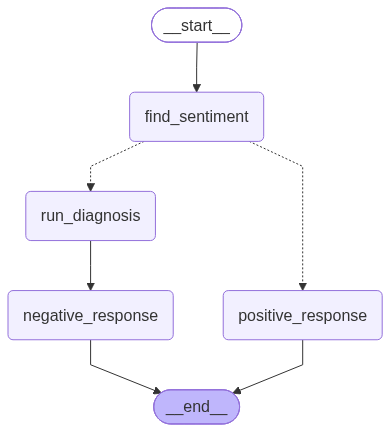

In [58]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())